# Klasifikasi Kelulusan Siswa dengan Random Forest

Dataset: Students Performance in Exams  
link : https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

Algoritma: Random Forest Classifier  
Target: Kelulusan siswa berdasarkan rata-rata ketiga skor (math, reading, writing) >= 70


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimpor.")

Library berhasil diimpor.


## 1. Memuat Dataset

In [ ]:
df = pd.read_csv('StudentsPerformance.csv')

print("Ukuran dataset:", df.shape)
df.head(10)

Ukuran dataset: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


## 2. Eksplorasi Data Awal

In [ ]:
print("Informasi Dataset:")
print("-" * 40)
df.info()

Informasi Dataset:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
print("Statistik Deskriptif:")
df.describe()

Statistik Deskriptif:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 3. Visualisasi Data

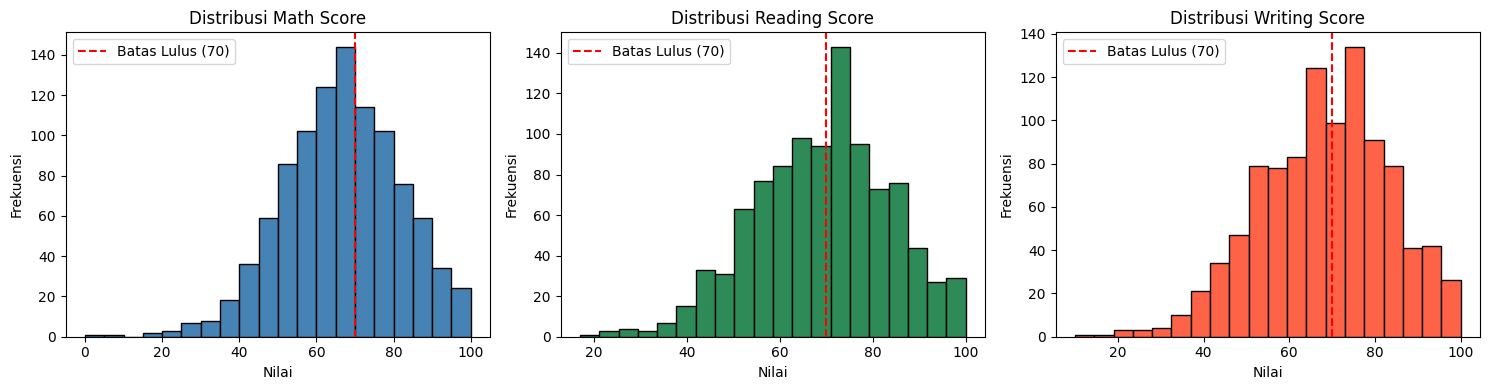

In [ ]:
score_cols = ['math score', 'reading score', 'writing score']
colors = ['steelblue', 'seagreen', 'tomato']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes, score_cols, colors):
    ax.hist(df[col], bins=20, color=color, edgecolor='black')
    ax.axvline(70, color='red', linestyle='--', linewidth=1.5, label='Batas Lulus (70)')
    ax.set_title(f'Distribusi {col.title()}')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.legend()

plt.tight_layout()
plt.show()

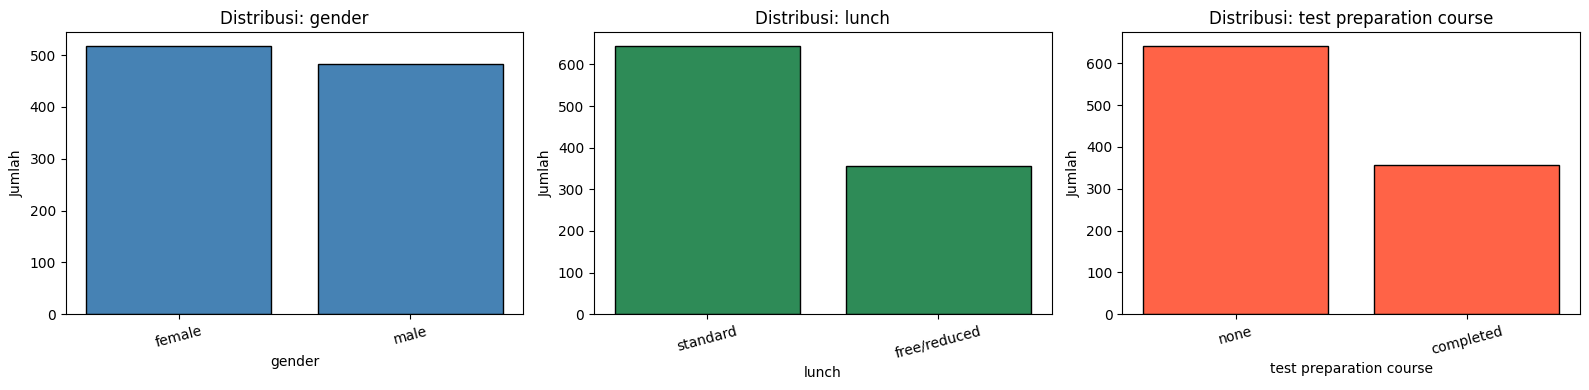

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cat_cols = ['gender', 'lunch', 'test preparation course']
colors_cat = ['steelblue', 'seagreen', 'tomato']

for i, (col, color) in enumerate(zip(cat_cols, colors_cat)):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=color, edgecolor='black')
    axes[i].set_title(f'Distribusi: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

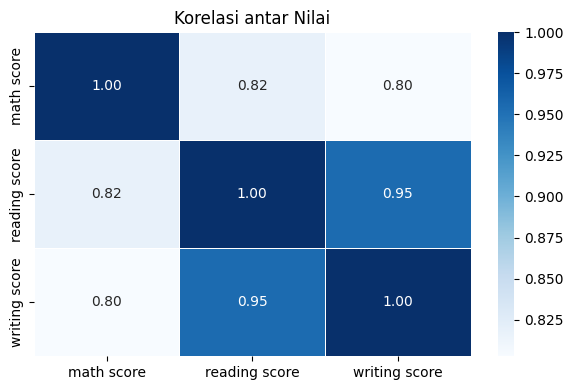

In [ ]:
plt.figure(figsize=(6, 4))
corr = df[['math score', 'reading score', 'writing score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Korelasi antar Nilai')
plt.tight_layout()
plt.show()

## 4. Membuat Label Kelulusan

Aturan kelulusan:
- Hitung rata-rata dari `math score`, `reading score`, dan `writing score`
- Jika rata-rata >= 70, maka siswa dinyatakan **Lulus (1)**
- Jika rata-rata < 70, maka siswa dinyatakan **Tidak Lulus (0)**


In [ ]:
df['average score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
df['lulus'] = (df['average score'] >= 70).astype(int)

print("Contoh data dengan kolom baru:")
print(df[['math score', 'reading score', 'writing score', 'average score', 'lulus']].head(10))

print(f"\nDistribusi label kelulusan:")
counts = df['lulus'].value_counts()
print(f"  Lulus       (1): {counts.get(1, 0)} siswa")
print(f"  Tidak Lulus (0): {counts.get(0, 0)} siswa")
print(f"  Persentase lulus: {counts.get(1, 0) / len(df) * 100:.1f}%")

Contoh data dengan kolom baru:
   math score  reading score  writing score  average score  lulus
0          72             72             74      72.666667      1
1          69             90             88      82.333333      1
2          90             95             93      92.666667      1
3          47             57             44      49.333333      0
4          76             78             75      76.333333      1
5          71             83             78      77.333333      1
6          88             95             92      91.666667      1
7          40             43             39      40.666667      0
8          64             64             67      65.000000      0
9          38             60             50      49.333333      0

Distribusi label kelulusan:
  Lulus       (1): 459 siswa
  Tidak Lulus (0): 541 siswa
  Persentase lulus: 45.9%


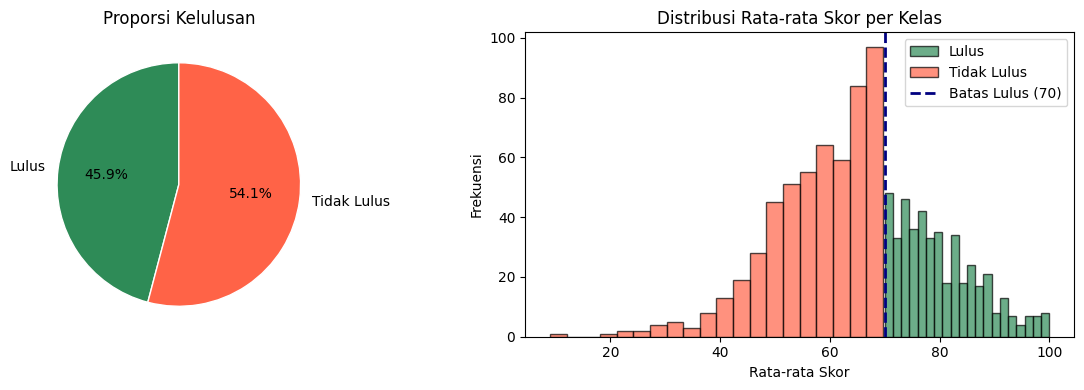

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = ['Lulus', 'Tidak Lulus']
sizes = [df['lulus'].sum(), (df['lulus'] == 0).sum()]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=['seagreen', 'tomato'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Proporsi Kelulusan')

axes[1].hist(df[df['lulus'] == 1]['average score'], bins=20, alpha=0.7,
             color='seagreen', edgecolor='black', label='Lulus')
axes[1].hist(df[df['lulus'] == 0]['average score'], bins=20, alpha=0.7,
             color='tomato', edgecolor='black', label='Tidak Lulus')
axes[1].axvline(70, color='navy', linestyle='--', linewidth=2, label='Batas Lulus (70)')
axes[1].set_title('Distribusi Rata-rata Skor per Kelas')
axes[1].set_xlabel('Rata-rata Skor')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Preprocessing

#### Pengecekan Missing Values

In [ ]:
print("Jumlah missing values per kolom:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Jumlah missing values per kolom:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
average score                  0
lulus                          0
dtype: int64

Total missing values: 0


#### Pengecekan Data Duplikat

In [ ]:
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat: {jumlah_duplikat}")

if jumlah_duplikat > 0:
    df = df.drop_duplicates()
    print(f"Duplikat berhasil dihapus. Ukuran dataset sekarang: {df.shape}")
else:
    print("Tidak ada duplikat. Dataset tetap:", df.shape)

Jumlah baris duplikat: 0
Tidak ada duplikat. Dataset tetap: (1000, 10)


#### Pengecekan dan Penanganan Outlier

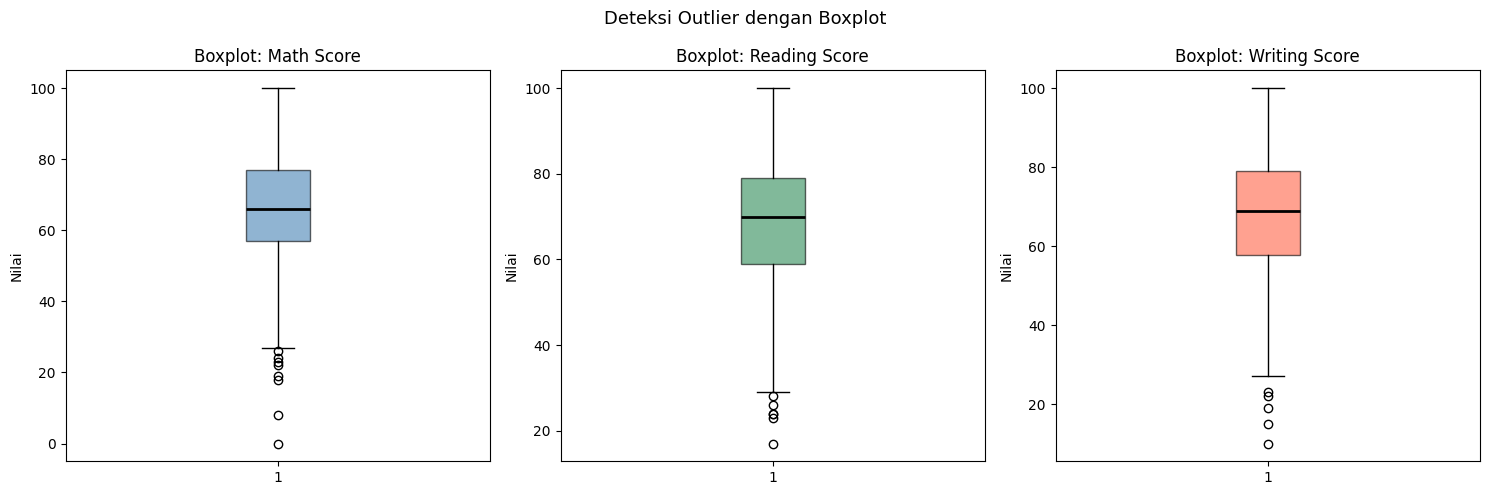

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes, score_cols, colors):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'Boxplot: {col.title()}')
    ax.set_ylabel('Nilai')

plt.suptitle('Deteksi Outlier dengan Boxplot', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
print("Deteksi Outlier menggunakan metode IQR:")
print("-" * 45)

for col in score_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR
    outlier = df[(df[col] < batas_bawah) | (df[col] > batas_atas)]
    print(f"{col}:")
    print(f"  Q1={Q1}, Q3={Q3}, IQR={IQR}")
    print(f"  Batas bawah={batas_bawah}, Batas atas={batas_atas}")
    print(f"  Jumlah outlier: {len(outlier)}")
    print()

Deteksi Outlier menggunakan metode IQR:
---------------------------------------------
math score:
  Q1=57.0, Q3=77.0, IQR=20.0
  Batas bawah=27.0, Batas atas=107.0
  Jumlah outlier: 8

reading score:
  Q1=59.0, Q3=79.0, IQR=20.0
  Batas bawah=29.0, Batas atas=109.0
  Jumlah outlier: 6

writing score:
  Q1=57.75, Q3=79.0, IQR=21.25
  Batas bawah=25.875, Batas atas=110.875
  Jumlah outlier: 5



In [ ]:
df_clean = df.copy()

for col in score_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= batas_bawah) & (df_clean[col] <= batas_atas)]

print(f"Ukuran dataset sebelum penanganan outlier : {df.shape}")
print(f"Ukuran dataset setelah penanganan outlier : {df_clean.shape}")
print(f"Jumlah baris yang dihapus                : {len(df) - len(df_clean)}")

Ukuran dataset sebelum penanganan outlier : (1000, 10)
Ukuran dataset setelah penanganan outlier : (986, 10)
Jumlah baris yang dihapus                : 14


### 5.2 Label Encoding

In [ ]:
cat_features = ['gender', 'race/ethnicity', 'parental level of education',
                'lunch', 'test preparation course']

le = LabelEncoder()
df_encoded = df_clean.copy()

for col in cat_features:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Encoding selesai. Contoh data setelah encoding:")
df_encoded[cat_features].head()

Encoding selesai. Contoh data setelah encoding:


,gender,race/ethnicity,parental level of education,lunch,test preparation course
0,0,1,1,1,1
1,0,2,4,1,0
2,0,1,3,1,1
3,1,0,0,0,1
4,1,2,4,1,1


### 5.3 Train Test Split

In [ ]:
feature_cols = ['gender', 'race/ethnicity', 'parental level of education',
                'lunch', 'test preparation course',
                'reading score', 'writing score']

X = df_encoded[feature_cols]
y = df_encoded['lulus']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Ukuran data latih : {X_train.shape}")
print(f"Ukuran data uji   : {X_test.shape}")
print(f"\nDistribusi kelas pada data latih:")
print(y_train.value_counts().rename({0: 'Tidak Lulus', 1: 'Lulus'}))
print(f"\nDistribusi kelas pada data uji:")
print(y_test.value_counts().rename({0: 'Tidak Lulus', 1: 'Lulus'}))

Ukuran data latih : (788, 7)
Ukuran data uji   : (198, 7)

Distribusi kelas pada data latih:
lulus
Tidak Lulus    421
Lulus          367
Name: count, dtype: int64

Distribusi kelas pada data uji:
lulus
Tidak Lulus    106
Lulus           92
Name: count, dtype: int64


## 6. Membangun Model Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,          # batasi kedalaman pohon
    min_samples_split=5,   # minimal sampel untuk split
    min_samples_leaf=2,    # minimal sampel di leaf
    random_state=42
)

rf_model.fit(X_train, y_train)
print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


## 7. Cross-Validation (5-Fold)

In [ ]:
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

print("Hasil Cross-Validation (5-Fold):")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nRata-rata Akurasi : {cv_scores.mean():.4f}")
print(f"Standar Deviasi   : {cv_scores.std():.4f}")

Hasil Cross-Validation (5-Fold):
  Fold 1: 0.9394
  Fold 2: 0.9543
  Fold 3: 0.9391
  Fold 4: 0.9594
  Fold 5: 0.9340

Rata-rata Akurasi : 0.9452
Standar Deviasi   : 0.0098


## 8. Evaluasi Model

In [ ]:
y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Akurasi: {acc:.4f} ({acc * 100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Tidak Lulus (0)', 'Lulus (1)']))

Akurasi: 0.9444 (94.44%)

Classification Report:
                 precision    recall  f1-score   support

Tidak Lulus (0)       0.93      0.97      0.95       106
      Lulus (1)       0.97      0.91      0.94        92

       accuracy                           0.94       198
      macro avg       0.95      0.94      0.94       198
   weighted avg       0.95      0.94      0.94       198



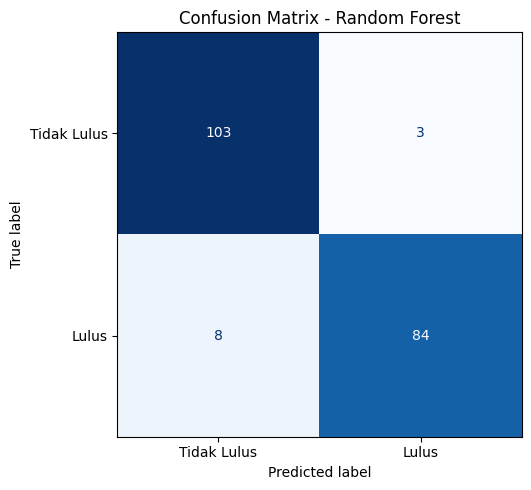

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Lulus', 'Lulus'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

## 9. Feature Importance

In [ ]:
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Fitur': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Tingkat Kepentingan Fitur:")
print(feature_importance_df.to_string(index=False))

Tingkat Kepentingan Fitur:
                      Fitur  Importance
              reading score    0.491369
              writing score    0.388188
             race/ethnicity    0.028150
parental level of education    0.025507
                     gender    0.024468
                      lunch    0.021949
    test preparation course    0.020369


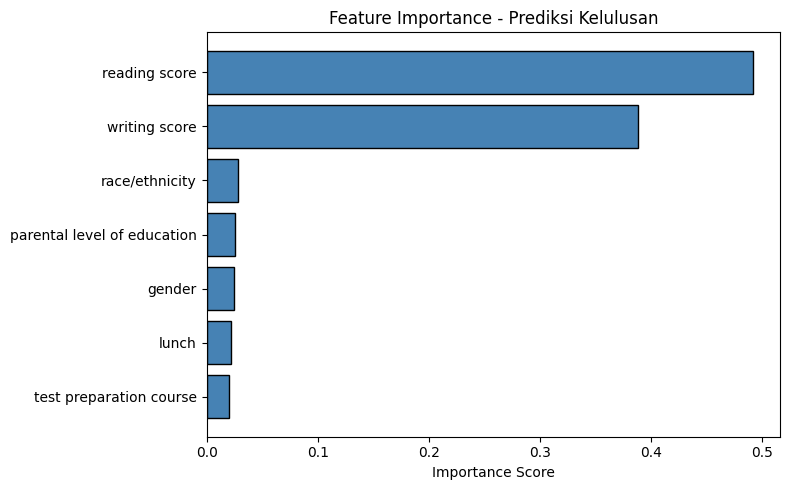

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance_df['Fitur'][::-1],
    feature_importance_df['Importance'][::-1],
    color='steelblue', edgecolor='black'
)
plt.xlabel('Importance Score')
plt.title('Feature Importance - Prediksi Kelulusan')
plt.tight_layout()
plt.show()